In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.optimize import curve_fit

In [4]:
#loading dataset
df_jute = pd.read_csv('Jute.csv', encoding='latin1')
df_syn = pd.read_csv('synthetic.csv')

In [5]:
df_jute.head()

,Time (Second),Temperature (Kelvin)
0,0,350.0
1,30,349.0
2,60,348.0
3,90,347.0
4,120,346.0


In [6]:
df_syn.head()

,Time,Temperature (Kelvin)
0,0,352.0
1,30,350.0
2,60,348.5
3,90,347.0
4,120,346.0


# **Trying various Equations Linear, Single Exponential, Double Exponential, polynomial regression**

Material     | Model                  | R2       | RMSE     | MAE
-----------------------------------------------------------------
Jute         | Linear                 | 0.9781   | 0.8385   | 0.6992
Jute         | 2nd-Order Polynomial   | 0.9966   | 0.3292   | 0.2665
Jute         | Single Exponential     | 0.9972   | 0.2981   | 0.2425
Jute         | 3rd-Order Polynomial   | 0.9975   | 0.2848   | 0.2275
Synthetic    | Linear                 | 0.8537   | 4.9549   | 4.1295
Synthetic    | 2nd-Order Polynomial   | 0.9905   | 1.2657   | 1.0495
Synthetic    | Single Exponential     | 0.9994   | 0.3170   | 0.2256
Synthetic    | Double Exponential     | 0.9994   | 0.3148   | 0.2213


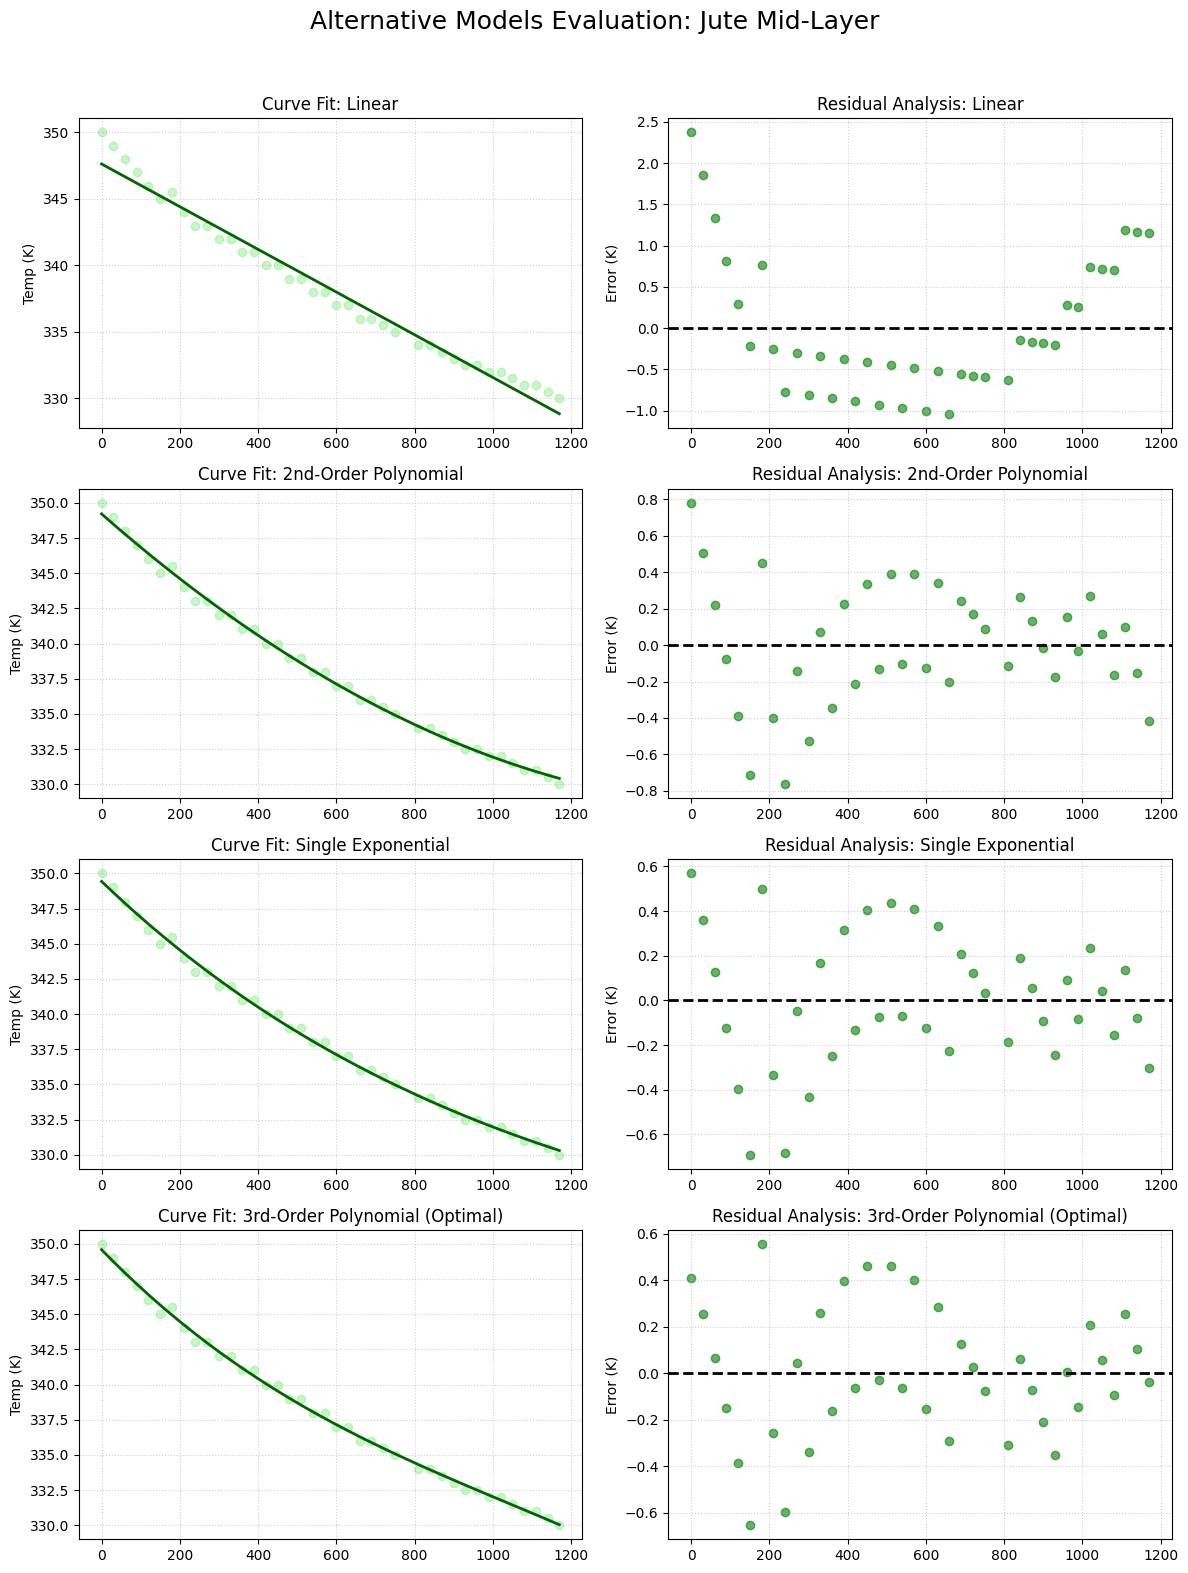

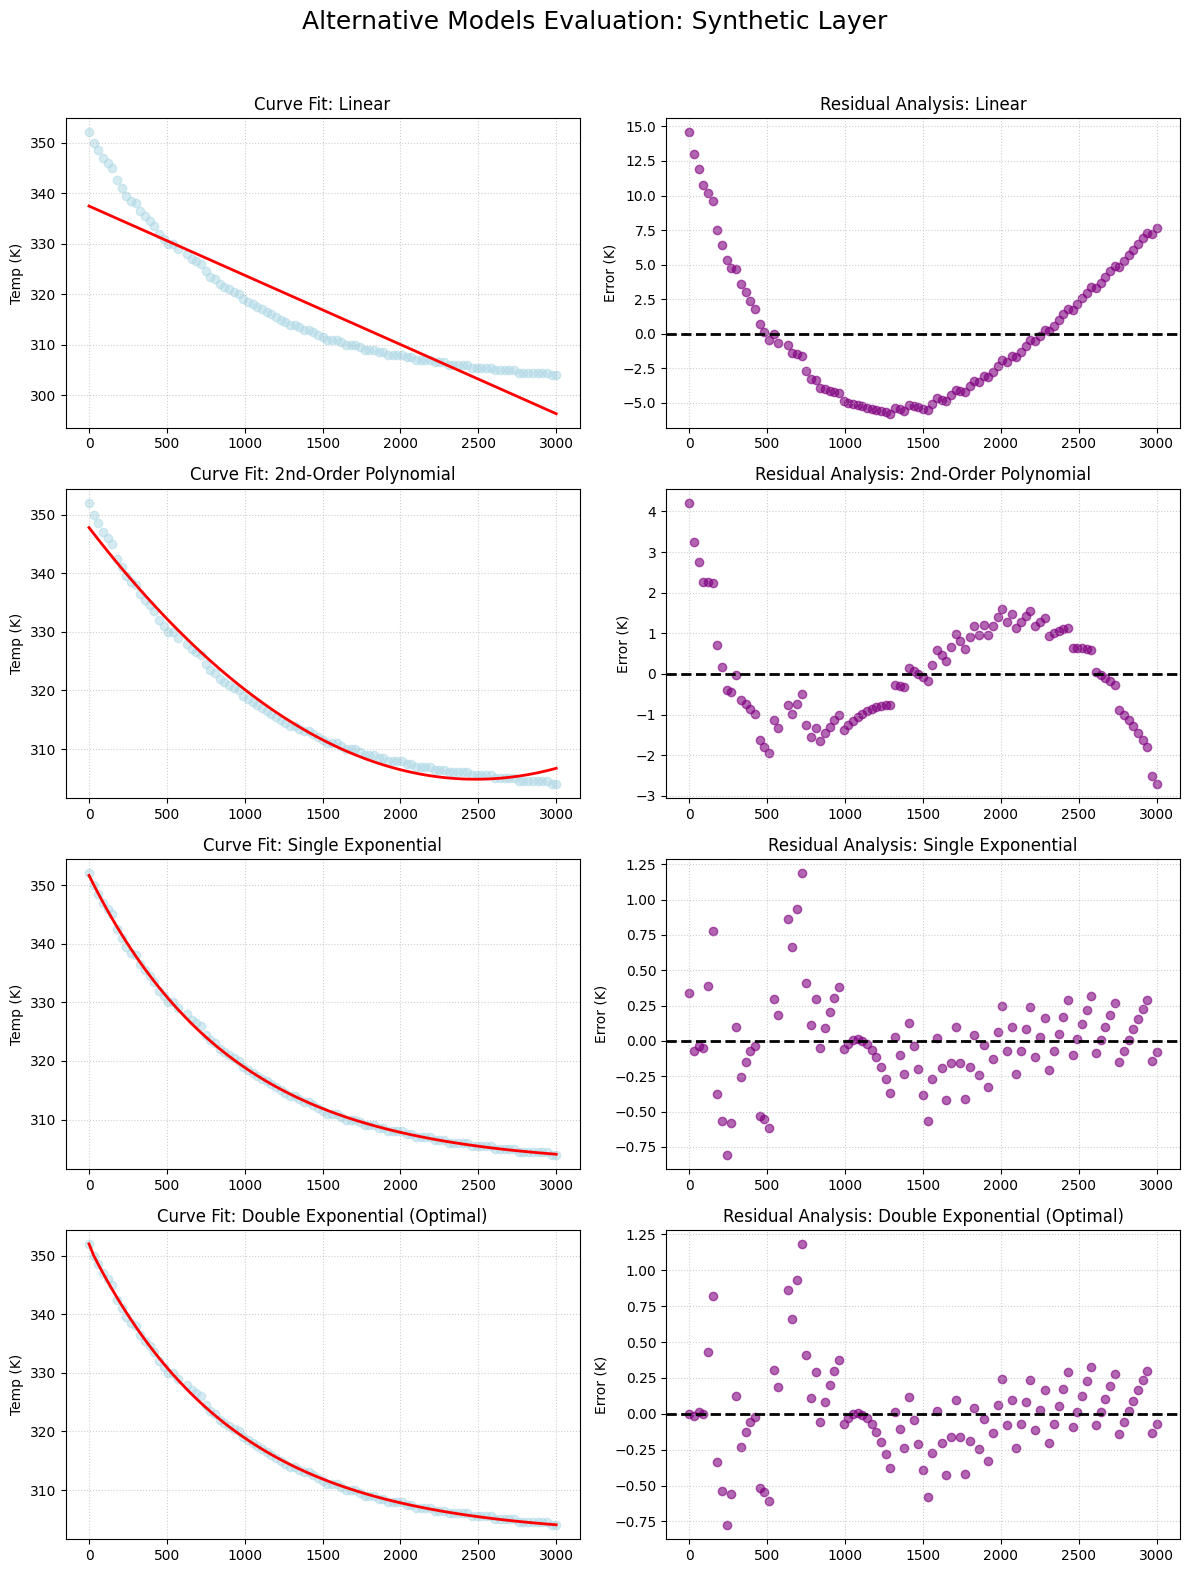

In [9]:

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings

# Suppress warnings for a clean output
warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# 1. LOAD AND CLEAN THE DATA
# ---------------------------------------------------------
df_jute = pd.read_csv('Jute.csv', encoding='latin1')
df_syn = pd.read_csv('synthetic.csv', encoding='latin1')

df_jute.iloc[:, 0] = pd.to_numeric(df_jute.iloc[:, 0], errors='coerce')
df_jute.iloc[:, 1] = pd.to_numeric(df_jute.iloc[:, 1], errors='coerce')
df_jute = df_jute.dropna()

df_syn.iloc[:, 0] = pd.to_numeric(df_syn.iloc[:, 0], errors='coerce')
df_syn.iloc[:, 1] = pd.to_numeric(df_syn.iloc[:, 1], errors='coerce')
df_syn = df_syn.dropna()

t_jute, T_jute = df_jute.iloc[:, 0].values, df_jute.iloc[:, 1].values
t_syn, T_syn = df_syn.iloc[:, 0].values, df_syn.iloc[:, 1].values

# ---------------------------------------------------------
# 2. DEFINE THE MATHEMATICAL MODELS
# ---------------------------------------------------------
def linear(x, a, b):
    return a * x + b

def single_exp(x, a, b, c):
    return a * np.exp(-b * x) + c

def double_exp(x, a, b, c, d, e):
    return a * np.exp(-b * x) + c * np.exp(-d * x) + e

# Helper function to easily calculate all metrics
def get_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return r2, rmse, mae

# ---------------------------------------------------------
# 3. FIT MODELS AND GATHER METRICS
# ---------------------------------------------------------
results = []

# --- Jute Fitting ---
popt, _ = curve_fit(linear, t_jute, T_jute)
pred_j_lin = linear(t_jute, *popt)
res_j_lin = T_jute - pred_j_lin
results.append(['Jute', 'Linear', *get_metrics(T_jute, pred_j_lin)])

popt_p2 = np.polyfit(t_jute, T_jute, 2)
pred_j_p2 = np.polyval(popt_p2, t_jute)
res_j_p2 = T_jute - pred_j_p2
results.append(['Jute', '2nd-Order Polynomial', *get_metrics(T_jute, pred_j_p2)])

popt, _ = curve_fit(single_exp, t_jute, T_jute, p0=[50, 0.001, 300])
pred_j_se = single_exp(t_jute, *popt)
res_j_se = T_jute - pred_j_se
results.append(['Jute', 'Single Exponential', *get_metrics(T_jute, pred_j_se)])

popt_p3 = np.polyfit(t_jute, T_jute, 3)
pred_j_p3 = np.polyval(popt_p3, t_jute)
res_j_p3 = T_jute - pred_j_p3
results.append(['Jute', '3rd-Order Polynomial', *get_metrics(T_jute, pred_j_p3)])

# --- Synthetic Fitting ---
popt, _ = curve_fit(linear, t_syn, T_syn)
pred_s_lin = linear(t_syn, *popt)
res_s_lin = T_syn - pred_s_lin
results.append(['Synthetic', 'Linear', *get_metrics(T_syn, pred_s_lin)])

popt_p2_s = np.polyfit(t_syn, T_syn, 2)
pred_s_p2 = np.polyval(popt_p2_s, t_syn)
res_s_p2 = T_syn - pred_s_p2
results.append(['Synthetic', '2nd-Order Polynomial', *get_metrics(T_syn, pred_s_p2)])

popt, _ = curve_fit(single_exp, t_syn, T_syn, p0=[50, 0.001, 300])
pred_s_se = single_exp(t_syn, *popt)
res_s_se = T_syn - pred_s_se
results.append(['Synthetic', 'Single Exponential', *get_metrics(T_syn, pred_s_se)])

popt, _ = curve_fit(double_exp, t_syn, T_syn, p0=[25, 0.001, 25, 0.01, 300], maxfev=10000)
pred_s_de = double_exp(t_syn, *popt)
res_s_de = T_syn - pred_s_de
results.append(['Synthetic', 'Double Exponential', *get_metrics(T_syn, pred_s_de)])

# Print the metrics nicely in the console
print(f"{'Material':<12} | {'Model':<22} | {'R2':<8} | {'RMSE':<8} | {'MAE'}")
print("-" * 65)
for row in results:
    print(f"{row[0]:<12} | {row[1]:<22} | {row[2]:.4f}   | {row[3]:.4f}   | {row[4]:.4f}")

# ---------------------------------------------------------
# 4. GENERATE JUTE PLOTS (4x2 Grid)
# ---------------------------------------------------------
fig1, axs1 = plt.subplots(4, 2, figsize=(12, 16))
fig1.suptitle('Alternative Models Evaluation: Jute Mid-Layer', fontsize=18, y=0.98)

models_jute = [
    ('Linear', pred_j_lin, res_j_lin),
    ('2nd-Order Polynomial', pred_j_p2, res_j_p2),
    ('Single Exponential', pred_j_se, res_j_se),
    ('3rd-Order Polynomial (Optimal)', pred_j_p3, res_j_p3)
]

for i, (name, pred, res) in enumerate(models_jute):
    # Fit Plot
    axs1[i, 0].scatter(t_jute, T_jute, color='lightgreen', alpha=0.5, label='Actual Data')
    axs1[i, 0].plot(t_jute, pred, color='darkgreen', lw=2, label='Model Fit')
    axs1[i, 0].set_title(f'Curve Fit: {name}', fontsize=12)
    axs1[i, 0].set_ylabel('Temp (K)')
    axs1[i, 0].grid(True, linestyle=':', alpha=0.6)

    # Residual Plot
    axs1[i, 1].scatter(t_jute, res, color='green', alpha=0.6)
    axs1[i, 1].axhline(0, color='black', ls='--', lw=2)
    axs1[i, 1].set_title(f'Residual Analysis: {name}', fontsize=12)
    axs1[i, 1].set_ylabel('Error (K)')
    axs1[i, 1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('Jute_Alternative_Models.png', dpi=300)

# ---------------------------------------------------------
# 5. GENERATE SYNTHETIC PLOTS (4x2 Grid)
# ---------------------------------------------------------
fig2, axs2 = plt.subplots(4, 2, figsize=(12, 16))
fig2.suptitle('Alternative Models Evaluation: Synthetic Layer', fontsize=18, y=0.98)

models_syn = [
    ('Linear', pred_s_lin, res_s_lin),
    ('2nd-Order Polynomial', pred_s_p2, res_s_p2),
    ('Single Exponential', pred_s_se, res_s_se),
    ('Double Exponential (Optimal)', pred_s_de, res_s_de)
]

for i, (name, pred, res) in enumerate(models_syn):
    # Fit Plot
    axs2[i, 0].scatter(t_syn, T_syn, color='lightblue', alpha=0.5, label='Actual Data')
    axs2[i, 0].plot(t_syn, pred, color='red', lw=2, label='Model Fit')
    axs2[i, 0].set_title(f'Curve Fit: {name}', fontsize=12)
    axs2[i, 0].set_ylabel('Temp (K)')
    axs2[i, 0].grid(True, linestyle=':', alpha=0.6)

    # Residual Plot
    axs2[i, 1].scatter(t_syn, res, color='purple', alpha=0.6)
    axs2[i, 1].axhline(0, color='black', ls='--', lw=2)
    axs2[i, 1].set_title(f'Residual Analysis: {name}', fontsize=12)
    axs2[i, 1].set_ylabel('Error (K)')
    axs2[i, 1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('Synthetic_Alternative_Models.png', dpi=300)
plt.show()

# **Selected Modelss for Jute and Synthetic**

In [7]:

df_jute = pd.read_csv('Jute.csv', encoding='latin1')
t_jute = df_jute.iloc[:, 0].values
T_jute_actual = df_jute.iloc[:, 1].values

df_syn = pd.read_csv('synthetic.csv', encoding='latin1')
t_syn = df_syn.iloc[:, 0].values
T_syn_actual = df_syn.iloc[:, 1].values

# 2. Define the Final Equations
def poly3_jute(x):
    return -5.09e-9 * (x**3) + 1.61e-5 * (x**2) - 0.0285 * x + 349.59

def double_exp_syn(t):
    return 49.44 * np.exp(-0.00108 * t) + 0.40 * np.exp(-0.52312 * t) + 302.15

# 3. Apply Models and Calculate Residuals
T_jute_pred = poly3_jute(t_jute)
res_jute = T_jute_actual - T_jute_pred

T_syn_pred = double_exp_syn(t_syn)
res_syn = T_syn_actual - T_syn_pred

# 4. Calculate Goodness-of-Fit Metrics
print("--- Jute Mid-Layer (3rd-Order Polynomial) ---")
print(f"R-squared: {r2_score(T_jute_actual, T_jute_pred):.5f}")
print(f"RMSE: {np.sqrt(mean_squared_error(T_jute_actual, T_jute_pred)):.4f} K")
print(f"MAE: {mean_absolute_error(T_jute_actual, T_jute_pred):.4f} K\n")

print("--- Synthetic Layer (Double Exponential) ---")
print(f"R-squared: {r2_score(T_syn_actual, T_syn_pred):.5f}")
print(f"RMSE: {np.sqrt(mean_squared_error(T_syn_actual, T_syn_pred)):.4f} K")
print(f"MAE: {mean_absolute_error(T_syn_actual, T_syn_pred):.4f} K")



--- Jute Mid-Layer (3rd-Order Polynomial) ---
R-squared: 0.99741
RMSE: 0.2886 K
MAE: 0.2336 K

--- Synthetic Layer (Double Exponential) ---
R-squared: 0.99940
RMSE: 0.3171 K
MAE: 0.2282 K




# **Plot the Results (2x2 Grid)**




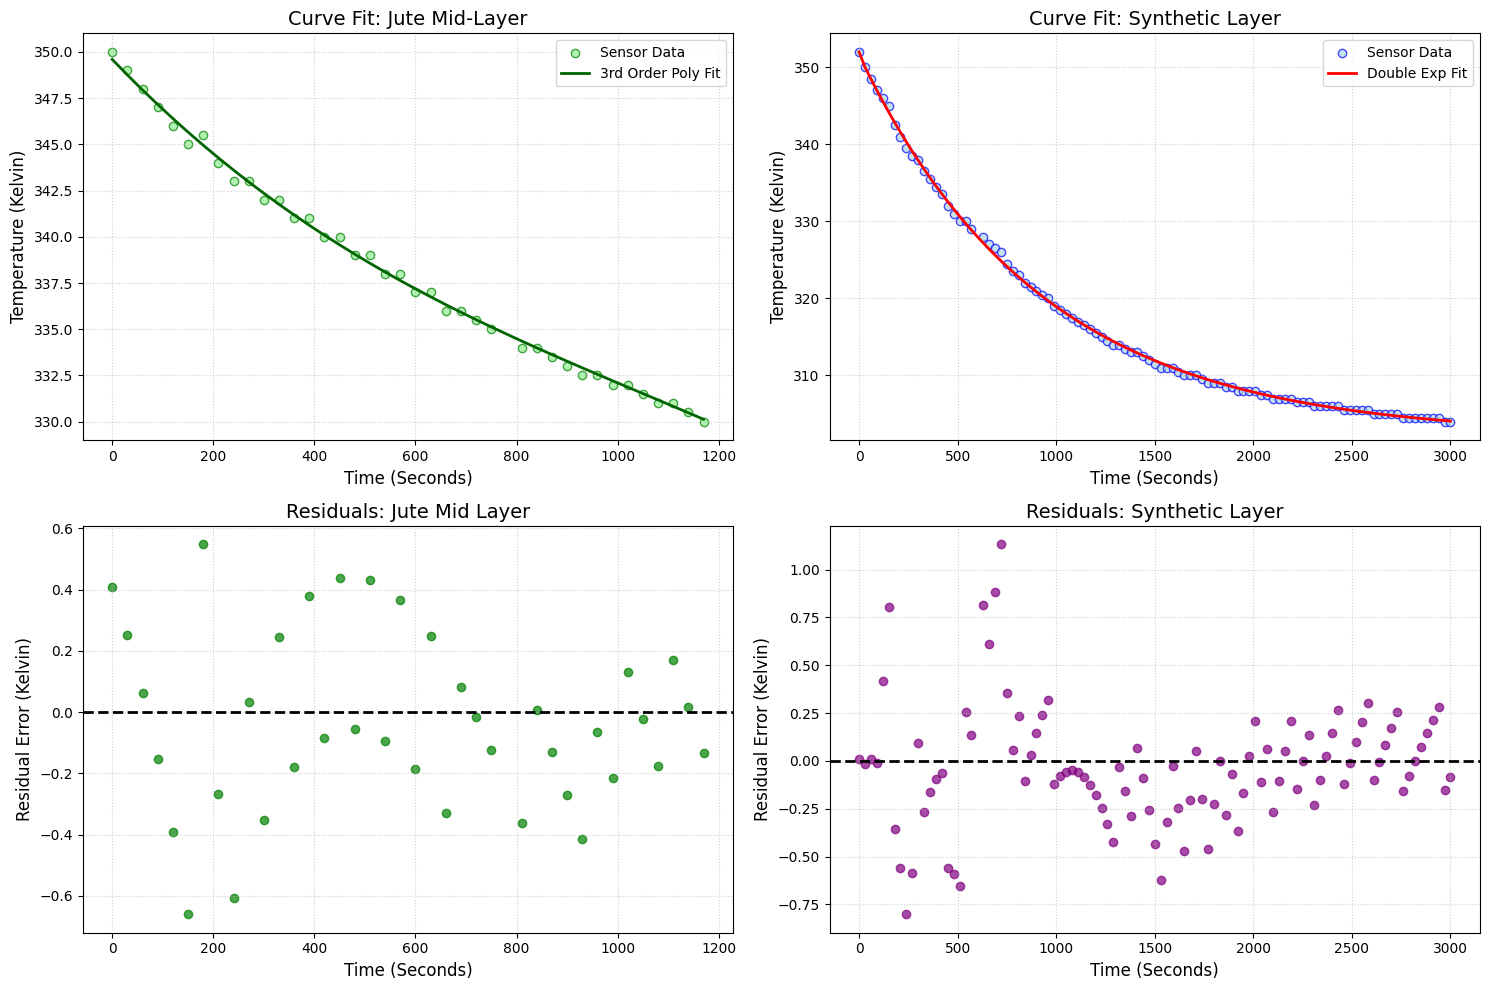

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

# Top Left: Jute Curve Fit
axs[0, 0].scatter(t_jute, T_jute_actual, color='lightgreen', edgecolor='green', alpha=0.7, label='Sensor Data')
axs[0, 0].plot(t_jute, T_jute_pred, color='darkgreen', linewidth=2, label='3rd Order Poly Fit')
axs[0, 0].set_title('Curve Fit: Jute Mid-Layer', fontsize=14)
axs[0, 0].set_xlabel('Time (Seconds)', fontsize=12)
axs[0, 0].set_ylabel('Temperature (Kelvin)', fontsize=12)
axs[0, 0].legend()
axs[0, 0].grid(True, linestyle=':', alpha=0.6)

# Top Right: Synthetic Curve Fit
axs[0, 1].scatter(t_syn, T_syn_actual, color='lightblue', edgecolor='blue', alpha=0.7, label='Sensor Data')
axs[0, 1].plot(t_syn, T_syn_pred, color='red', linewidth=2, label='Double Exp Fit')
axs[0, 1].set_title('Curve Fit: Synthetic Layer', fontsize=14)
axs[0, 1].set_xlabel('Time (Seconds)', fontsize=12)
axs[0, 1].set_ylabel('Temperature (Kelvin)', fontsize=12)
axs[0, 1].legend()
axs[0, 1].grid(True, linestyle=':', alpha=0.6)

# Bottom Left: Jute Residuals
axs[1, 0].scatter(t_jute, res_jute, color='green', alpha=0.7)
axs[1, 0].axhline(y=0, color='black', linestyle='--', linewidth=2)
axs[1, 0].set_title('Residuals: Jute Mid Layer', fontsize=14)
axs[1, 0].set_xlabel('Time (Seconds)', fontsize=12)
axs[1, 0].set_ylabel('Residual Error (Kelvin)', fontsize=12)
axs[1, 0].grid(True, linestyle=':', alpha=0.6)

# Bottom Right: Synthetic Residuals
axs[1, 1].scatter(t_syn, res_syn, color='purple', alpha=0.7)
axs[1, 1].axhline(y=0, color='black', linestyle='--', linewidth=2)
axs[1, 1].set_title('Residuals: Synthetic Layer', fontsize=14)
axs[1, 1].set_xlabel('Time (Seconds)', fontsize=12)
axs[1, 1].set_ylabel('Residual Error (Kelvin)', fontsize=12)
axs[1, 1].grid(True, linestyle=':', alpha=0.6)

# Adjust layout and save the image
plt.tight_layout()
# Uncomment the line below to save the file to your computer
# plt.savefig('Final_Cooling_Models.png', dpi=300)
plt.show()